### Grace Burns
## Northwestern University
## January 2026

# Phase 2 Database Analysis — PostgreSQL & MongoDB
| Retail Customer Behavior for Growth | Burns G.

Answers the five business research questions using direct database queries against the
Phase 2 polyglot persistence layer. No machine learning models are used — all analysis
is performed through SQL (PostgreSQL star schema) and aggregation pipelines (MongoDB Customer 360).

| Section | Business Question | Database |
|---------|-------------------|----------|
| 1 | Imports & connections | — |
| 2 | Q1: How do customer spending patterns evolve over time? | PostgreSQL |
| 3 | Q2: How do demographic characteristics influence spending? | PostgreSQL |
| 4 | Q3: Which product categories drive revenue growth? | PostgreSQL |
| 5 | Q4: Are campaigns effective, and which types generate the most lift? | PostgreSQL + MongoDB |
| 6 | Q5: Is there evidence of trade-down under price pressure? | PostgreSQL |
| 7 | Customer segmentation & at-risk identification | PostgreSQL + MongoDB |
| 8 | MongoDB Customer 360 — audience queries | MongoDB |

### Date mapping
Day 1 = January 1 2023 → Day 711 = December 11 2024. Weeks 1–16 are a ramp-up artefact;
Week 102 is a hard truncation. Both are flagged in `ext_calendar.window_flag` and excluded
from steady-state analysis where noted.

---
## Section 1 — Imports, Config & Connections

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import socket
from sqlalchemy import create_engine, text
from pymongo import MongoClient

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ── PostgreSQL ────────────────────────────────────────────────────────────────
PG_HOST = '127.0.0.1'
PG_PORT = 5434
PG_DB   = 'retail_analytics'
PG_USER = 'retail_user'
PG_PASS = 'retail_pass'

engine = create_engine(
    f'postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}',
    pool_pre_ping=True
)

# ── MongoDB ───────────────────────────────────────────────────────────────────
MONGO_URI  = 'mongodb://localhost:27017/?directConnection=true'
MONGO_DB   = 'retail_customer360'
MONGO_COLL = 'households'

mongo_client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=3000)
mongo_db     = mongo_client[MONGO_DB]
coll         = mongo_db[MONGO_COLL]

# ── Connectivity check ────────────────────────────────────────────────────────
for host, port in [('127.0.0.1', PG_PORT), ('127.0.0.1', 27017)]:
    try:
        s = socket.create_connection((host, port), timeout=2)
        s.close()
        print(f'OPEN: {host}:{port}')
    except OSError:
        print(f'CLOSED: {host}:{port}')

OPEN: 127.0.0.1:5434
OPEN: 127.0.0.1:27017


In [2]:
# Quick database health check
with engine.connect() as conn:
    version = conn.execute(text('SELECT version()')).scalar()
    n_txn   = conn.execute(text('SELECT COUNT(*) FROM fact_transactions')).scalar()
    n_hh    = conn.execute(text('SELECT COUNT(*) FROM dim_households')).scalar()

print(f'PostgreSQL : {version.split(" on ")[0]}')
print(f'fact_transactions : {n_txn:,} rows')
print(f'dim_households    : {n_hh:,} rows')

n_mongo = coll.count_documents({})
print(f'MongoDB households collection : {n_mongo:,} documents')

PostgreSQL : PostgreSQL 16.13 (Debian 16.13-1.pgdg13+1)
fact_transactions : 1,427,303 rows
dim_households    : 924 rows
MongoDB households collection : 924 documents


## Store Metrics for query runs

In [69]:
import time
from datetime import datetime, timezone
import pandas as pd
from sqlalchemy import text

# Central store for all timing records
query_metrics = []

def log_metric(label, elapsed_ms, rows=None, source="sql", status="ok", error=None, notes=None):
    query_metrics.append({
        "metric_label": label,
        "source": source,
        "elapsed_ms": round(elapsed_ms, 3),
        "rows": rows,
        "status": status,
        "error": str(error)[:300] if error is not None else None,
        "notes": notes,
        "recorded_at": datetime.now(timezone.utc)
    })

def run_sql_timed(label, sql, engine, params=None):
    t0 = time.perf_counter()
    try:
        with engine.connect() as conn:
            df = pd.read_sql(text(sql), conn, params=params)
        elapsed_ms = (time.perf_counter() - t0) * 1000
        log_metric(label, elapsed_ms, rows=len(df), source="sql", status="ok")
        return df
    except Exception as e:
        elapsed_ms = (time.perf_counter() - t0) * 1000
        log_metric(label, elapsed_ms, rows=None, source="sql", status="error", error=e)
        raise

def run_mongo_timed(label, coll, pipeline):
    t0 = time.perf_counter()
    try:
        docs = list(coll.aggregate(pipeline))
        df = pd.DataFrame(docs)
        elapsed_ms = (time.perf_counter() - t0) * 1000
        log_metric(label, elapsed_ms, rows=len(df), source="mongo", status="ok")
        return df
    except Exception as e:
        elapsed_ms = (time.perf_counter() - t0) * 1000
        log_metric(label, elapsed_ms, rows=None, source="mongo", status="error", error=e)
        raise

def benchmark_sql(label, sql, engine, repeats=5, params=None):
    timings = []
    last_df = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        with engine.connect() as conn:
            last_df = pd.read_sql(text(sql), conn, params=params)
        timings.append((time.perf_counter() - t0) * 1000)

    result = {
        "metric_label": label,
        "source": "sql",
        "avg_ms": round(pd.Series(timings).mean(), 3),
        "median_ms": round(pd.Series(timings).median(), 3),
        "p95_ms": round(pd.Series(timings).quantile(0.95), 3),
        "min_ms": round(min(timings), 3),
        "max_ms": round(max(timings), 3),
        "runs": repeats,
        "rows": len(last_df) if last_df is not None else None,
        "recorded_at": datetime.now(timezone.utc)
    }
    return result, last_df

def benchmark_mongo(label, coll, pipeline, repeats=5):
    timings = []
    last_docs = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        last_docs = list(coll.aggregate(pipeline))
        timings.append((time.perf_counter() - t0) * 1000)

    result = {
        "metric_label": label,
        "source": "mongo",
        "avg_ms": round(pd.Series(timings).mean(), 3),
        "median_ms": round(pd.Series(timings).median(), 3),
        "p95_ms": round(pd.Series(timings).quantile(0.95), 3),
        "min_ms": round(min(timings), 3),
        "max_ms": round(max(timings), 3),
        "runs": repeats,
        "rows": len(last_docs) if last_docs is not None else None,
        "recorded_at": datetime.now(timezone.utc)
    }
    return result, pd.DataFrame(last_docs)

---
## Section 2 — Q1: Customer Spending Trends

**Business question:** How do customer spending patterns evolve over time, and what drives
week-to-week variation?

Key flags from `ext_calendar`:
- `is_rampup = TRUE` → Weeks 1–16, panel recruitment artefact, excluded from steady-state stats
- `is_truncation = TRUE` → Week 102, partial week, excluded from steady-state stats

In [70]:
with engine.connect() as conn:
    cols = pd.read_sql("""
        SELECT column_name
        FROM information_schema.columns
        WHERE table_name = 'ext_calendar'
        ORDER BY ordinal_position
    """, conn)

print(cols)

     column_name
0        day_int
1  calendar_date
2           year
3          month
4   week_of_year
5       week_num
6      is_rampup
7  is_truncation


In [71]:
from sqlalchemy import text
import pandas as pd

SQL_Q1A = """
SELECT
    ec.week_num,
    MIN(ec.calendar_date) AS week_start_date,
    COUNT(DISTINCT t.basket_id) AS baskets,
    COUNT(DISTINCT t.household_key) AS active_households,
    ROUND(SUM(t.sales_value)::numeric, 2) AS total_spend,
    ROUND(
        (SUM(t.sales_value) / NULLIF(COUNT(DISTINCT t.household_key), 0))::numeric,
        2
    ) AS spend_per_hh,
    CASE
        WHEN ec.is_rampup THEN 'Ramp-up (Wks 1-16)'
        WHEN ec.is_truncation THEN 'Truncation (Wk 102)'
        ELSE 'Steady state'
    END AS window_flag
FROM fact_transactions t
JOIN ext_calendar ec
    ON ec.day_int = t.day
GROUP BY
    ec.week_num,
    ec.is_rampup,
    ec.is_truncation
ORDER BY ec.week_num
"""

with engine.connect() as conn:
    df_weekly = pd.read_sql(text(SQL_Q1A), conn)

print(f"Weeks observed : {len(df_weekly)}")
print(f"  Ramp-up      : {(df_weekly['window_flag'] == 'Ramp-up (Wks 1-16)').sum()}")
print(f"  Steady state : {(df_weekly['window_flag'] == 'Steady state').sum()}")
print(f"  Truncation   : {(df_weekly['window_flag'] == 'Truncation (Wk 102)').sum()}")

Weeks observed : 102
  Ramp-up      : 16
  Steady state : 85
  Truncation   : 1


In [72]:
SQL_Q1B = """
SELECT
    ROUND(MIN(wk.total_spend)::numeric, 0) AS min_weekly_spend,
    ROUND(MAX(wk.total_spend)::numeric, 0) AS max_weekly_spend,
    ROUND(AVG(wk.total_spend)::numeric, 0) AS avg_weekly_spend,
    ROUND(
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY wk.total_spend)::numeric,
        0
    ) AS median_weekly_spend
FROM (
    SELECT
        ec.week_num,
        SUM(t.sales_value) AS total_spend
    FROM fact_transactions t
    JOIN ext_calendar ec
        ON ec.day_int = t.day
    WHERE NOT ec.is_rampup
      AND NOT ec.is_truncation
    GROUP BY ec.week_num
) wk
"""

In [73]:
with engine.connect() as conn:
    df_check = pd.read_sql("""
        SELECT day_int, COUNT(*) AS n
        FROM ext_calendar
        GROUP BY day_int
        HAVING COUNT(*) > 1
        ORDER BY n DESC, day_int
    """, conn)

print(df_check.head())

Empty DataFrame
Columns: [day_int, n]
Index: []


In [74]:
with engine.connect() as conn:
    df_weeks = pd.read_sql("""
        SELECT COUNT(DISTINCT ec.week_num) AS steady_state_weeks
        FROM fact_transactions t
        JOIN ext_calendar ec
            ON ec.day_int = t.day
        WHERE NOT ec.is_rampup
          AND NOT ec.is_truncation
    """, conn)

print(df_weeks)

   steady_state_weeks
0                  85


In [75]:
# Q1b — Steady-state summary statistics
SQL_Q1B = """
SELECT
    ROUND(MIN(wk.total_spend)::numeric, 0)    AS min_weekly_spend,
    ROUND(MAX(wk.total_spend)::numeric, 0)    AS max_weekly_spend,
    ROUND(AVG(wk.total_spend)::numeric, 0)    AS avg_weekly_spend,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP
          (ORDER BY wk.total_spend)::numeric, 0) AS median_weekly_spend
FROM (
    SELECT
        ec.week_num,
        SUM(t.sales_value) AS total_spend
    FROM fact_transactions t
    JOIN ext_calendar ec ON ec.day_int = t.day
    WHERE ec.is_rampup = FALSE AND ec.is_truncation = FALSE
    GROUP BY ec.week_num
) wk
"""

with engine.connect() as conn:
    df_ss = pd.read_sql(text(SQL_Q1B), conn)

print('Steady-state summary ($):')
print(f'  Min weekly spend : ${df_ss.min_weekly_spend.iloc[0]:,.0f}')
print(f'  Max weekly spend : ${df_ss.max_weekly_spend.iloc[0]:,.0f}')
print(f'  Avg weekly spend : ${df_ss.avg_weekly_spend.iloc[0]:,.0f}')
print(f'  Median           : ${df_ss.median_weekly_spend.iloc[0]:,.0f}')

Steady-state summary ($):
  Min weekly spend : $38,996
  Max weekly spend : $58,304
  Avg weekly spend : $49,050
  Median           : $49,329


In [45]:
with engine.connect() as conn:
    df_weeks = pd.read_sql("""
        SELECT COUNT(DISTINCT ec.week_num) AS steady_state_weeks
        FROM fact_transactions t
        JOIN ext_calendar ec
            ON ec.day_int = t.day
        WHERE NOT ec.is_rampup
          AND NOT ec.is_truncation
    """, conn)

print(df_weeks)

   steady_state_weeks
0                  85


Avg YoY change: +33.5%


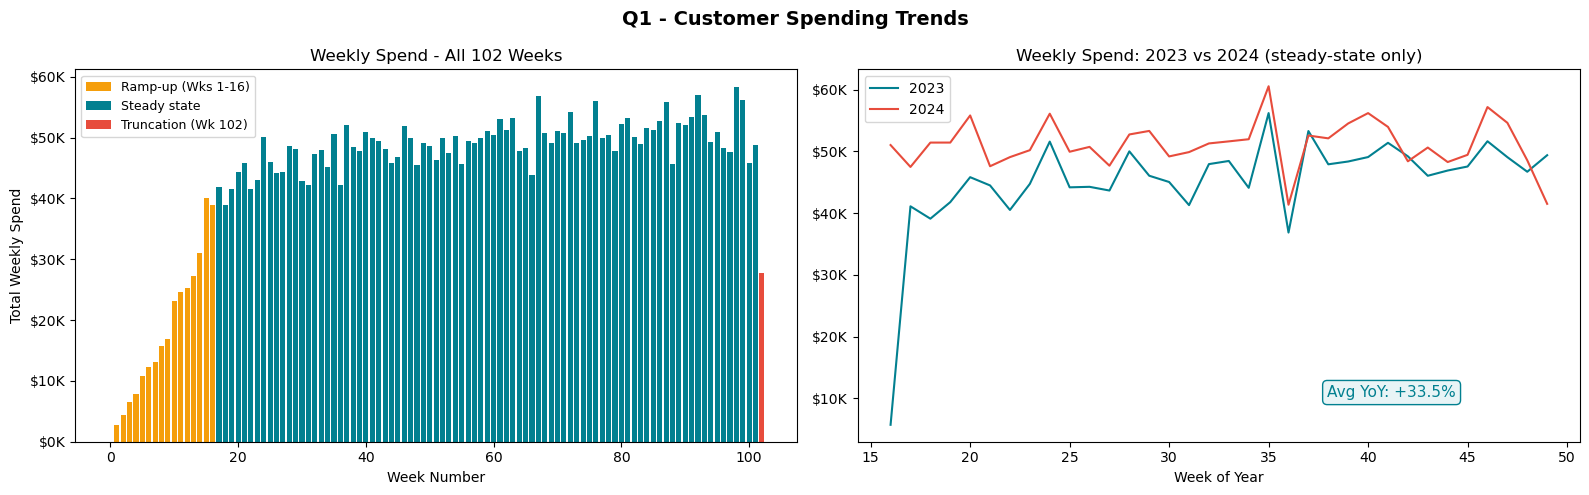

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

# Q1c — Year-on-year comparison: 2023 vs 2024 (steady-state weeks only)
SQL_Q1C = """
SELECT
    ec.year,
    ec.week_of_year,
    ROUND(SUM(t.sales_value)::numeric, 2) AS total_spend,
    COUNT(DISTINCT t.household_key) AS active_hh
FROM fact_transactions t
JOIN ext_calendar ec
    ON ec.day_int = t.day
WHERE NOT ec.is_rampup
  AND NOT ec.is_truncation
GROUP BY ec.year, ec.week_of_year
ORDER BY ec.year, ec.week_of_year
"""

with engine.connect() as conn:
    df_yoy = pd.read_sql(text(SQL_Q1C), conn)

df_2023 = df_yoy[df_yoy['year'] == 2023].copy()
df_2024 = df_yoy[df_yoy['year'] == 2024].copy()

merged = df_2023.merge(
    df_2024,
    on='week_of_year',
    suffixes=('_2023', '_2024')
).sort_values('week_of_year').reset_index(drop=True)

merged['yoy_pct'] = np.where(
    merged['total_spend_2023'] != 0,
    (merged['total_spend_2024'] - merged['total_spend_2023']) / merged['total_spend_2023'] * 100,
    np.nan
)

avg_yoy = merged['yoy_pct'].mean()
print(f'Avg YoY change: {avg_yoy:+.1f}%')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Q1 - Customer Spending Trends', fontweight='bold', fontsize=14)

# Chart 1: Weekly spend all weeks, colour-coded
colours = df_weekly['window_flag'].map({
    'Ramp-up (Wks 1-16)': '#F59E0B',
    'Steady state': '#028090',
    'Truncation (Wk 102)': '#E74C3C'
})

axes[0].bar(df_weekly['week_num'], df_weekly['total_spend'], color=colours, width=0.8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].set_xlabel('Week Number')
axes[0].set_ylabel('Total Weekly Spend')
axes[0].set_title('Weekly Spend - All 102 Weeks')

for label, colour in [
    ('Ramp-up (Wks 1-16)', '#F59E0B'),
    ('Steady state', '#028090'),
    ('Truncation (Wk 102)', '#E74C3C')
]:
    axes[0].bar(0, 0, color=colour, label=label)

axes[0].legend(fontsize=9)

# Chart 2: YoY overlay using matched weeks only
axes[1].plot(merged['week_of_year'], merged['total_spend_2023'], label='2023', color='#028090', linewidth=1.5)
axes[1].plot(merged['week_of_year'], merged['total_spend_2024'], label='2024', color='#E74C3C', linewidth=1.5)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_xlabel('Week of Year')
axes[1].set_title('Weekly Spend: 2023 vs 2024 (steady-state only)')
axes[1].legend()

axes[1].annotate(
    f'Avg YoY: {avg_yoy:+.1f}%',
    xy=(0.65, 0.12),
    xycoords='axes fraction',
    fontsize=11,
    color='#028090',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F4F6', edgecolor='#028090')
)

plt.tight_layout()
plt.show()

---
## Section 3 — Q2: Demographic Influences on Spending

**Business question:** How do demographic characteristics influence household spending behaviour?

Note: classification columns live in `dim_demographics`, not `dim_households`.
Join path: `fact_transactions → dim_demographics` via `household_key`.

In [47]:
from sqlalchemy import text
import pandas as pd

# Q2a - Signal strength: spend spread across all 7 classification variables
SQL_Q2A = """
WITH hh_spend AS (
    SELECT
        household_key,
        SUM(sales_value) AS lifetime_spend
    FROM fact_transactions
    GROUP BY household_key
)
SELECT
    classification,
    COUNT(DISTINCT level_value) AS n_levels,
    ROUND(MIN(grp_avg)::numeric, 0) AS min_group_avg,
    ROUND(MAX(grp_avg)::numeric, 0) AS max_group_avg,
    ROUND((MAX(grp_avg) - MIN(grp_avg))::numeric, 0) AS spend_spread
FROM (
    SELECT
        'classification_1' AS classification,
        d.classification_1 AS level_value,
        AVG(s.lifetime_spend) AS grp_avg
    FROM dim_demographics d
    JOIN hh_spend s USING (household_key)
    WHERE d.classification_1 IS NOT NULL
    GROUP BY d.classification_1

    UNION ALL

    SELECT
        'classification_2',
        d.classification_2,
        AVG(s.lifetime_spend)
    FROM dim_demographics d
    JOIN hh_spend s USING (household_key)
    WHERE d.classification_2 IS NOT NULL
    GROUP BY d.classification_2

    UNION ALL

    SELECT
        'classification_3',
        d.classification_3,
        AVG(s.lifetime_spend)
    FROM dim_demographics d
    JOIN hh_spend s USING (household_key)
    WHERE d.classification_3 IS NOT NULL
    GROUP BY d.classification_3

    UNION ALL

    SELECT
        'classification_4',
        d.classification_4,
        AVG(s.lifetime_spend)
    FROM dim_demographics d
    JOIN hh_spend s USING (household_key)
    WHERE d.classification_4 IS NOT NULL
    GROUP BY d.classification_4

    UNION ALL

    SELECT
        'classification_5',
        d.classification_5,
        AVG(s.lifetime_spend)
    FROM dim_demographics d
    JOIN hh_spend s USING (household_key)
    WHERE d.classification_5 IS NOT NULL
    GROUP BY d.classification_5

    UNION ALL

    SELECT
        'classification_6',
        d.classification_6,
        AVG(s.lifetime_spend)
    FROM dim_demographics d
    JOIN hh_spend s USING (household_key)
    WHERE d.classification_6 IS NOT NULL
    GROUP BY d.classification_6

    UNION ALL

    SELECT
        'classification_7',
        d.classification_7,
        AVG(s.lifetime_spend)
    FROM dim_demographics d
    JOIN hh_spend s USING (household_key)
    WHERE d.classification_7 IS NOT NULL
    GROUP BY d.classification_7
) t
GROUP BY classification
ORDER BY spend_spread DESC
"""

with engine.connect() as conn:
    df_signal = pd.read_sql(text(SQL_Q2A), conn)

df_signal["signal_rank"] = range(1, len(df_signal) + 1)
print(df_signal.to_string(index=False))

  classification  n_levels  min_group_avg  max_group_avg  spend_spread  signal_rank
classification_3        12       4,097.00      10,790.00      6,693.00            1
classification_1         6       4,241.00       6,403.00      2,162.00            2
classification_4         5       4,305.00       6,022.00      1,717.00            3
classification_5         5       5,032.00       6,699.00      1,666.00            4
classification_6         6       4,831.00       6,473.00      1,642.00            5
classification_7         4       5,299.00       6,764.00      1,465.00            6
classification_2         3       5,118.00       6,137.00      1,018.00            7


In [48]:
from sqlalchemy import text
import pandas as pd

# Q2b - classification_3 full breakdown
SQL_Q2B = """
WITH hh_spend AS (
    SELECT
        household_key,
        SUM(sales_value) AS lifetime_spend
    FROM fact_transactions
    GROUP BY household_key
)
SELECT
    d.classification_3,
    COUNT(DISTINCT d.household_key) AS n_households,
    ROUND(AVG(s.lifetime_spend)::numeric, 2) AS avg_lifetime_spend,
    ROUND(
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY s.lifetime_spend)::numeric,
        2
    ) AS median_spend,
    ROUND(MIN(s.lifetime_spend)::numeric, 2) AS min_spend,
    ROUND(MAX(s.lifetime_spend)::numeric, 2) AS max_spend
FROM dim_demographics d
JOIN hh_spend s USING (household_key)
WHERE d.classification_3 IS NOT NULL
GROUP BY d.classification_3
ORDER BY avg_lifetime_spend DESC
"""

with engine.connect() as conn:
    df_c3 = pd.read_sql(text(SQL_Q2B), conn)

spread = df_c3["avg_lifetime_spend"].max() - df_c3["avg_lifetime_spend"].min()

print(df_c3.to_string(index=False))
print(f"\nSpend spread: ${spread:,.0f}")

classification_3  n_households  avg_lifetime_spend  median_spend  min_spend  max_spend
         Level12            11           10,789.90     11,938.20   1,523.80  17,152.63
         Level10            11            8,548.46      6,644.85   1,103.88  23,646.92
          Level9            30            8,394.84      8,437.10   1,132.40  18,494.14
          Level8            38            7,912.06      6,004.79   1,095.10  27,859.68
          Level7            34            5,927.74      5,949.72   1,510.63  19,194.42
          Level6            96            5,822.53      4,881.04   1,290.68  17,548.27
         Level11             5            5,726.49      5,399.64   2,206.06  10,435.96
          Level5           192            5,702.35      4,980.15     748.88  17,295.18
          Level1            61            5,559.61      4,827.80   1,602.00  19,153.75
          Level3            77            4,938.07      4,405.47     760.45  19,299.86
          Level4           172            4

classification_2  n_households  avg_lifetime_spend  median_spend  pct_of_total_spend
               X           340            6,136.65      5,055.86               46.40
               Y           344            5,268.64      4,450.50               40.30
               Z           117            5,118.33      4,526.21               13.30

Top group (X) premium over #2: $868


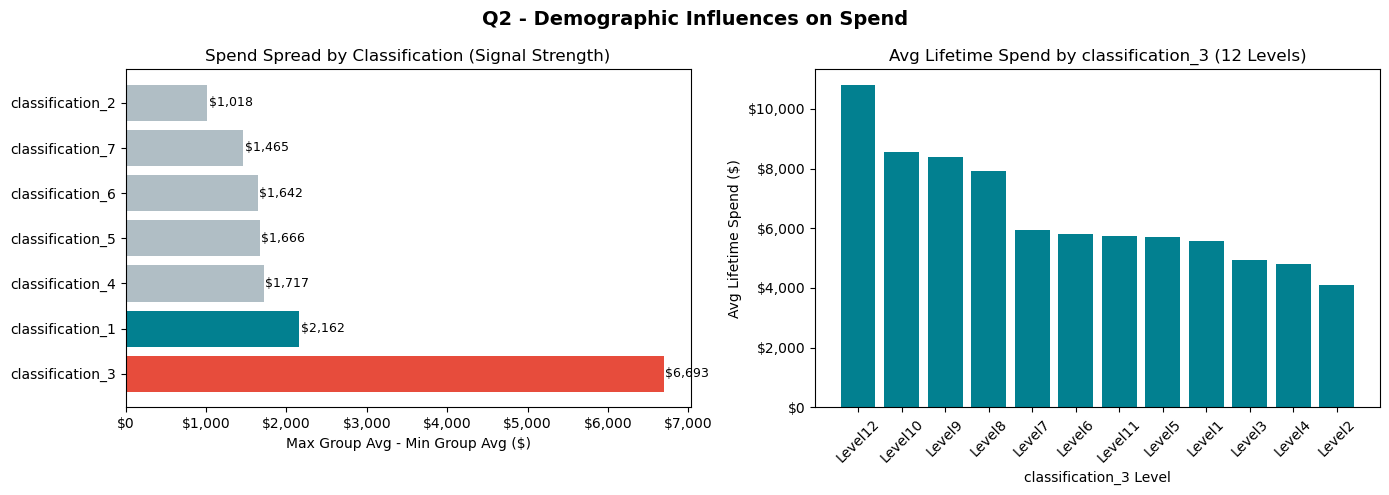

In [49]:
# Q2c - classification_2 group premium
SQL_Q2C = """
WITH hh_spend AS (
    SELECT
        household_key,
        SUM(sales_value) AS lifetime_spend
    FROM fact_transactions
    GROUP BY household_key
)
SELECT
    d.classification_2,
    COUNT(DISTINCT d.household_key) AS n_households,
    ROUND(AVG(s.lifetime_spend)::numeric, 2) AS avg_lifetime_spend,
    ROUND(
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY s.lifetime_spend)::numeric,
        2
    ) AS median_spend,
    ROUND(
        SUM(s.lifetime_spend) * 100.0
        / SUM(SUM(s.lifetime_spend)) OVER ()::numeric,
        1
    ) AS pct_of_total_spend
FROM dim_demographics d
JOIN hh_spend s USING (household_key)
WHERE d.classification_2 IS NOT NULL
GROUP BY d.classification_2
ORDER BY avg_lifetime_spend DESC
"""

with engine.connect() as conn:
    df_c2 = pd.read_sql(text(SQL_Q2C), conn)

print(df_c2.to_string(index=False))

if len(df_c2) >= 2:
    premium = df_c2['avg_lifetime_spend'].iloc[0] - df_c2['avg_lifetime_spend'].iloc[1]
    print(f"\nTop group ({df_c2['classification_2'].iloc[0]}) premium over #2: ${premium:,.0f}")
else:
    print("\nNot enough groups to calculate premium over #2.")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q2 - Demographic Influences on Spend', fontweight='bold', fontsize=14)

# Signal strength chart
colours_sig = [
    '#E74C3C' if r == 1 else '#028090' if r == 2 else '#B0BEC5'
    for r in df_signal['signal_rank']
]

axes[0].barh(df_signal['classification'], df_signal['spend_spread'], color=colours_sig)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(df_signal['spend_spread']):
    axes[0].text(v + 20, i, f'${v:,.0f}', va='center', fontsize=9)
axes[0].set_title('Spend Spread by Classification (Signal Strength)')
axes[0].set_xlabel('Max Group Avg - Min Group Avg ($)')

# classification_3 breakdown
axes[1].bar(df_c3['classification_3'], df_c3['avg_lifetime_spend'], color='#028090')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xlabel('classification_3 Level')
axes[1].set_ylabel('Avg Lifetime Spend ($)')
axes[1].set_title('Avg Lifetime Spend by classification_3 (12 Levels)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Section 4 — Q3: Product Category Growth

**Business question:** Which product categories are driving revenue growth, and how concentrated is the revenue base?

In [50]:
SQL_Q3A = """
SELECT
    p.department,
    ROUND(SUM(t.sales_value)::numeric, 2) AS total_revenue,
    ROUND(
        SUM(t.sales_value) * 100.0
        / SUM(SUM(t.sales_value)) OVER ()::numeric,
        2
    ) AS revenue_share_pct,
    ROUND(
        SUM(SUM(t.sales_value)) OVER (
            ORDER BY SUM(t.sales_value) DESC, p.department
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) * 100.0
        / SUM(SUM(t.sales_value)) OVER ()::numeric,
        1
    ) AS cumulative_share_pct,
    DENSE_RANK() OVER (ORDER BY SUM(t.sales_value) DESC, p.department) AS revenue_rank
FROM fact_transactions t
JOIN dim_products p USING (product_id)
WHERE p.department IS NOT NULL
GROUP BY p.department
ORDER BY total_revenue DESC
"""

with engine.connect() as conn:
    df_dept = pd.read_sql(text(SQL_Q3A), conn)

top_n = min(5, len(df_dept))
top5_cum = df_dept['cumulative_share_pct'].iloc[top_n - 1]

print(df_dept.head(10).to_string(index=False))
print(f"\nTop {top_n} departments cumulative share: {top5_cum:.1f}%")

     department  total_revenue  revenue_share_pct  cumulative_share_pct  revenue_rank
        GROCERY   2,259,606.63              50.24                 50.20             1
        DRUG GM     587,586.20              13.06                 63.30             2
      KIOSK-GAS     342,108.62               7.61                 70.90             3
        PRODUCE     327,421.67               7.28                 78.20             4
           MEAT     293,014.55               6.51                 84.70             5
     MEAT-PCKGD     209,210.24               4.65                 89.40             6
           DELI     148,062.87               3.29                 92.60             7
MISC SALES TRAN      70,771.09               1.57                 94.20             8
         PASTRY      65,535.96               1.46                 95.70             9
      NUTRITION      60,288.90               1.34                 97.00            10

Top 5 departments cumulative share: 84.7%


     department  revenue_2023  revenue_2024  yoy_growth_pct  revenue_rank
        GROCERY    850,898.90  1,240,617.45           45.80             1
        DRUG GM    223,763.55    317,845.40           42.00             2
      KIOSK-GAS    125,384.67    201,744.24           60.90             3
        PRODUCE    118,779.78    183,570.95           54.50             4
           MEAT    111,105.09    158,945.78           43.10             5
     MEAT-PCKGD     78,388.34    113,913.78           45.30             6
           DELI     54,154.89     82,262.82           51.90             7
MISC SALES TRAN     25,232.86     42,010.64           66.50             8
         PASTRY     24,765.19     35,881.40           44.90             9
      NUTRITION     22,092.40     34,514.98           56.20            10


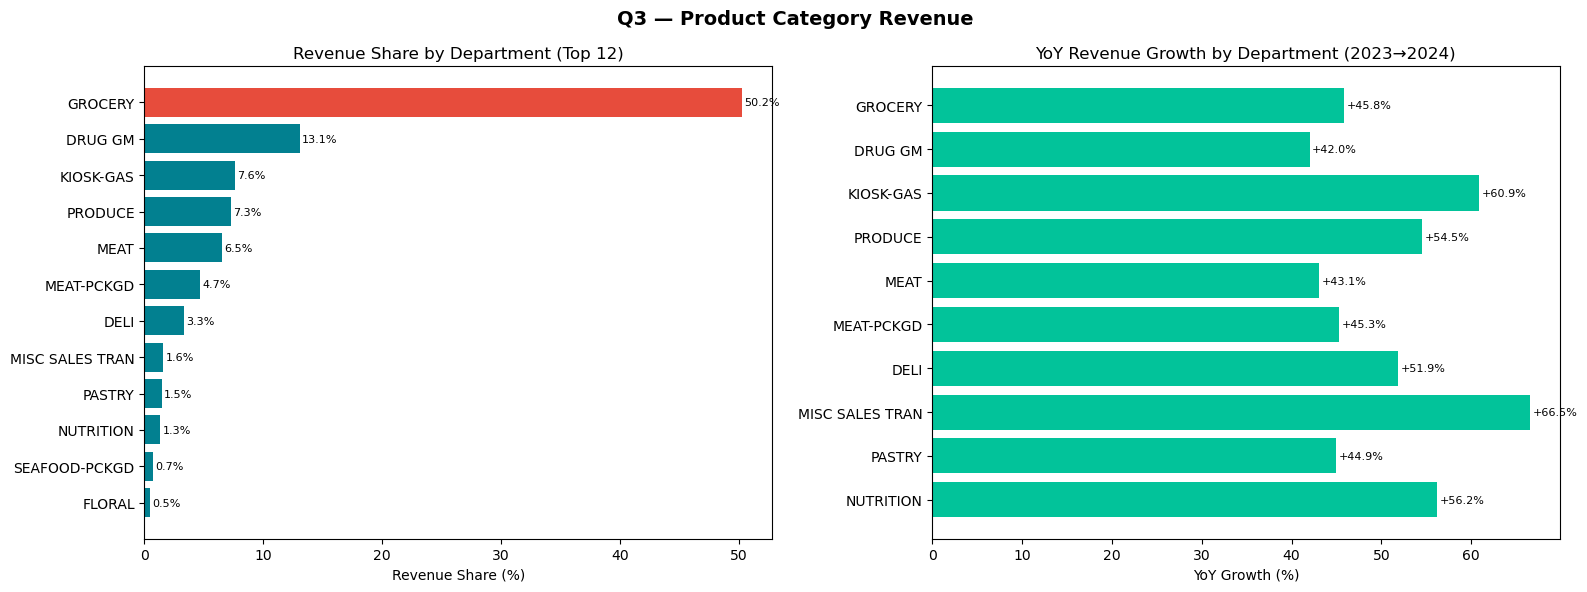

In [51]:
# Q3b — YoY revenue growth by department (2023 vs 2024, top 15 depts)
SQL_Q3B = """
SELECT
    p.department,
    ROUND(SUM(CASE WHEN ec.year = 2023 THEN t.sales_value ELSE 0 END)::numeric, 2) AS revenue_2023,
    ROUND(SUM(CASE WHEN ec.year = 2024 THEN t.sales_value ELSE 0 END)::numeric, 2) AS revenue_2024,
    ROUND(
        (SUM(CASE WHEN ec.year = 2024 THEN t.sales_value ELSE 0 END) -
         SUM(CASE WHEN ec.year = 2023 THEN t.sales_value ELSE 0 END))
        * 100.0 /
        NULLIF(SUM(CASE WHEN ec.year = 2023 THEN t.sales_value ELSE 0 END), 0)::numeric
    , 1) AS yoy_growth_pct,
    RANK() OVER (ORDER BY SUM(t.sales_value) DESC) AS revenue_rank
FROM fact_transactions t
JOIN dim_products p USING (product_id)
JOIN ext_calendar ec ON ec.day_int = t.day
WHERE p.department IS NOT NULL
  AND ec.is_rampup = FALSE AND ec.is_truncation = FALSE
GROUP BY p.department
HAVING SUM(t.sales_value) > 50000
ORDER BY revenue_rank
LIMIT 15
"""

with engine.connect() as conn:
    df_yoy_dept = pd.read_sql(text(SQL_Q3B), conn)

print(df_yoy_dept.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q3 — Product Category Revenue', fontweight='bold', fontsize=14)

top12 = df_dept.head(12)
colours_dept = ['#E74C3C' if r == 1 else '#028090' for r in top12.revenue_rank]
axes[0].barh(top12.department[::-1], top12.revenue_share_pct[::-1], color=colours_dept[::-1])
for i, v in enumerate(top12.revenue_share_pct[::-1]):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=8)
axes[0].set_title('Revenue Share by Department (Top 12)')
axes[0].set_xlabel('Revenue Share (%)')

axes[1].barh(df_yoy_dept.department[::-1], df_yoy_dept.yoy_growth_pct[::-1], color='#02C39A')
for i, v in enumerate(df_yoy_dept.yoy_growth_pct[::-1]):
    axes[1].text(v + 0.3, i, f'+{v:.1f}%', va='center', fontsize=8)
axes[1].set_title('YoY Revenue Growth by Department (2023→2024)')
axes[1].set_xlabel('YoY Growth (%)')

plt.tight_layout()
plt.show()

     department  revenue_2023  revenue_2024  yoy_growth_pct  revenue_rank
        GROCERY    850,898.90  1,240,617.45           45.80             1
        DRUG GM    223,763.55    317,845.40           42.00             2
      KIOSK-GAS    125,384.67    201,744.24           60.90             3
        PRODUCE    118,779.78    183,570.95           54.50             4
           MEAT    111,105.09    158,945.78           43.10             5
     MEAT-PCKGD     78,388.34    113,913.78           45.30             6
           DELI     54,154.89     82,262.82           51.90             7
MISC SALES TRAN     25,232.86     42,010.64           66.50             8
         PASTRY     24,765.19     35,881.40           44.90             9
      NUTRITION     22,092.40     34,514.98           56.20            10
  SEAFOOD-PCKGD     12,722.32     17,743.15           39.50            11
         FLORAL      7,743.08     11,920.22           53.90            12
      COSMETICS      6,891.49     10,7

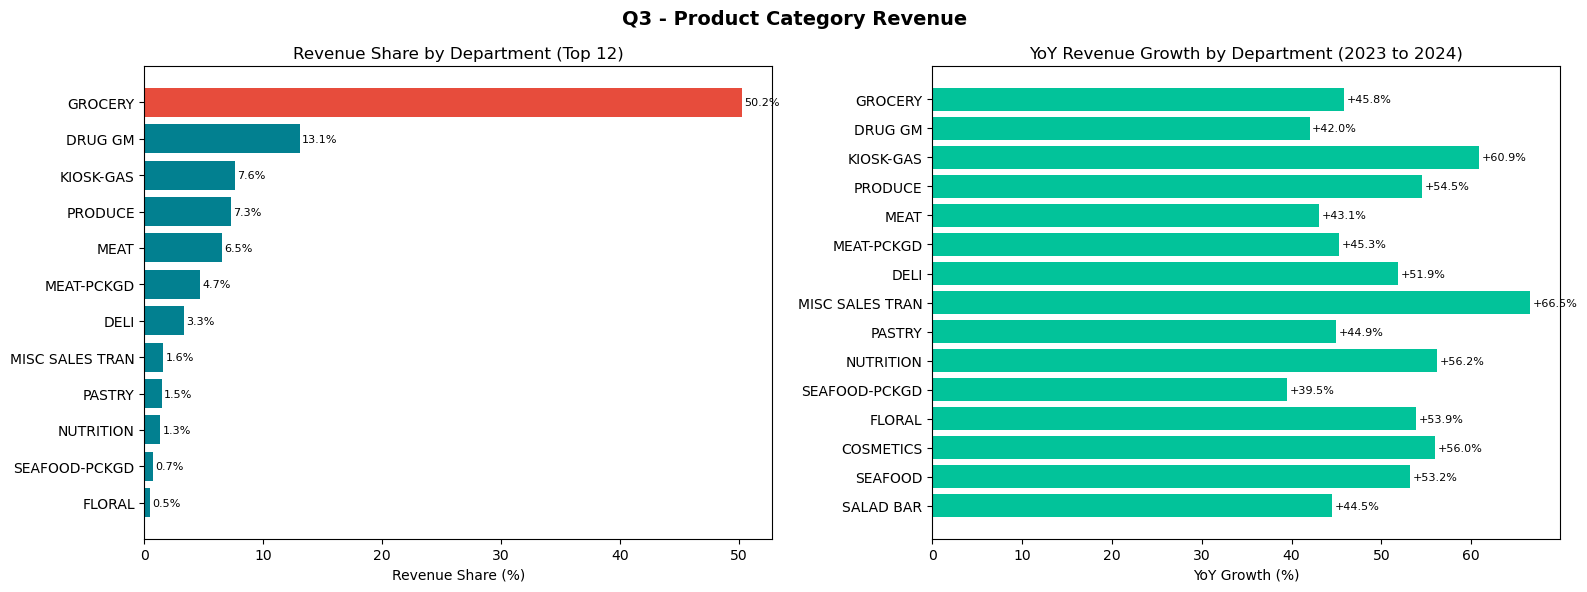

In [52]:
# Q3b - YoY revenue growth by department (2023 vs 2024, top 15 depts)
SQL_Q3B = """
SELECT
    p.department,
    ROUND(SUM(CASE WHEN ec.year = 2023 THEN t.sales_value ELSE 0 END)::numeric, 2) AS revenue_2023,
    ROUND(SUM(CASE WHEN ec.year = 2024 THEN t.sales_value ELSE 0 END)::numeric, 2) AS revenue_2024,
    ROUND(
        (
            SUM(CASE WHEN ec.year = 2024 THEN t.sales_value ELSE 0 END) -
            SUM(CASE WHEN ec.year = 2023 THEN t.sales_value ELSE 0 END)
        ) * 100.0
        / NULLIF(SUM(CASE WHEN ec.year = 2023 THEN t.sales_value ELSE 0 END), 0)::numeric,
        1
    ) AS yoy_growth_pct,
    DENSE_RANK() OVER (ORDER BY SUM(t.sales_value) DESC) AS revenue_rank
FROM fact_transactions t
JOIN dim_products p USING (product_id)
JOIN ext_calendar ec ON ec.day_int = t.day
WHERE p.department IS NOT NULL
  AND NOT ec.is_rampup
  AND NOT ec.is_truncation
GROUP BY p.department
ORDER BY revenue_rank
LIMIT 15
"""

with engine.connect() as conn:
    df_yoy_dept = pd.read_sql(text(SQL_Q3B), conn)

print(df_yoy_dept.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q3 - Product Category Revenue', fontweight='bold', fontsize=14)

top12 = df_dept.head(12).copy()
colours_dept = ['#E74C3C' if r == 1 else '#028090' for r in top12['revenue_rank']]

axes[0].barh(top12['department'][::-1], top12['revenue_share_pct'][::-1], color=colours_dept[::-1])
for i, v in enumerate(top12['revenue_share_pct'][::-1]):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=8)
axes[0].set_title('Revenue Share by Department (Top 12)')
axes[0].set_xlabel('Revenue Share (%)')

axes[1].barh(df_yoy_dept['department'][::-1], df_yoy_dept['yoy_growth_pct'][::-1], color='#02C39A')
for i, v in enumerate(df_yoy_dept['yoy_growth_pct'][::-1]):
    x_pos = v + 0.3 if v >= 0 else v - 0.3
    ha = 'left' if v >= 0 else 'right'
    axes[1].text(x_pos, i, f'{v:+.1f}%', va='center', ha=ha, fontsize=8)

axes[1].set_title('YoY Revenue Growth by Department (2023 to 2024)')
axes[1].set_xlabel('YoY Growth (%)')

plt.tight_layout()
plt.show()

---
## Section 5 — Q4: Campaign Effectiveness

**Business question:** Are campaigns effective at driving spend, and which campaign types generate the most lift?

Method: Difference-in-Differences (DiD) in SQL.
For each household × campaign event, compare spend during the campaign window
to spend in the 28-day pre-window. Lift = during spend – pre spend.
Group by campaign type and RFM segment.

In [53]:
# Q4a — DiD: spend lift by campaign type
SQL_Q4A = """
WITH events AS (
    SELECT
        ct.household_key,
        ct.campaign_id,
        cd.campaign_type,
        cd.start_day,
        cd.end_day
    FROM campaign_table ct
    JOIN dim_campaigns cd ON ct.campaign_id = cd.campaign_id
),
pre AS (
    SELECT
        e.household_key,
        e.campaign_id,
        COUNT(DISTINCT t.basket_id)         AS pre_trips,
        COALESCE(SUM(t.sales_value), 0)     AS pre_spend
    FROM events e
    JOIN fact_transactions t
      ON t.household_key = e.household_key
     AND t.day >= e.start_day - 28
     AND t.day <  e.start_day
    GROUP BY e.household_key, e.campaign_id
),
dur AS (
    SELECT
        e.household_key,
        e.campaign_id,
        COUNT(DISTINCT t.basket_id)         AS dur_trips,
        COALESCE(SUM(t.sales_value), 0)     AS dur_spend
    FROM events e
    JOIN fact_transactions t
      ON t.household_key = e.household_key
     AND t.day >= e.start_day
     AND t.day <= e.end_day
    GROUP BY e.household_key, e.campaign_id
)
SELECT
    e.campaign_type,
    COUNT(*)                                                       AS n_events,
    ROUND(AVG(COALESCE(p.pre_spend,0))::numeric, 2)               AS avg_pre_spend,
    ROUND(AVG(COALESCE(d.dur_spend,0))::numeric, 2)               AS avg_dur_spend,
    ROUND(AVG(COALESCE(d.dur_spend,0) -
              COALESCE(p.pre_spend,0))::numeric, 2)               AS avg_spend_lift,
    ROUND(AVG(CASE WHEN COALESCE(p.pre_spend,0) > 0
                   THEN (COALESCE(d.dur_spend,0) - p.pre_spend)
                        / p.pre_spend * 100 END)::numeric, 1)     AS avg_pct_lift,
    ROUND(AVG(COALESCE(d.dur_trips,0) -
              COALESCE(p.pre_trips,0))::numeric, 1)               AS avg_trip_lift
FROM events e
LEFT JOIN pre p ON p.household_key = e.household_key AND p.campaign_id = e.campaign_id
LEFT JOIN dur d ON d.household_key = e.household_key AND d.campaign_id = e.campaign_id
WHERE COALESCE(p.pre_trips, 0) >= 1
GROUP BY e.campaign_type
ORDER BY avg_spend_lift DESC
"""

with engine.connect() as conn:
    df_did = pd.read_sql(text(SQL_Q4A), conn)

print('Campaign lift by type (DiD — 28-day pre-window):')
print(df_did.to_string(index=False))

Campaign lift by type (DiD — 28-day pre-window):
campaign_type  n_events  avg_pre_spend  avg_dur_spend  avg_spend_lift  avg_pct_lift  avg_trip_lift
        TypeC       355         379.31         894.15          514.84        287.80          13.20
        TypeA      2154         271.53         493.80          222.26        172.90           6.60
        TypeB      1656         362.97         472.64          109.67         69.50           2.90


In [76]:
# Q4b — DiD lift by campaign type × RFM segment (from MongoDB)
# Pull RFM segments from MongoDB and join to DiD SQL result
rfm_docs = list(coll.find(
    {'rfm_segment': {'$exists': True}},
    {'household_key': 1, 'rfm_segment': 1, '_id': 0}
))
df_rfm = pd.DataFrame(rfm_docs)
print(f'RFM segments loaded from MongoDB: {len(df_rfm):,} households')
print(df_rfm.rfm_segment.value_counts().to_string())

RFM segments loaded from MongoDB: 801 households
rfm_segment
Other        262
At Risk      139
Champions    130
Loyal        122
Potential     83
New           65


Avg spend lift by RFM segment × campaign type:
rfm_segment campaign_type  avg_spend_lift
  Champions         TypeA          396.92
  Potential         TypeA          231.77
      Loyal         TypeA          215.82
    At Risk         TypeA          198.54
        New         TypeA          150.00
      Other         TypeA          131.21
  Champions         TypeB          166.40
      Loyal         TypeB          106.22
  Potential         TypeB           94.55
    At Risk         TypeB           88.09
      Other         TypeB           65.83
        New         TypeB           62.81
  Champions         TypeC          710.47
  Potential         TypeC          520.26
        New         TypeC          455.25
    At Risk         TypeC          447.84
      Loyal         TypeC          417.89
      Other         TypeC          314.44


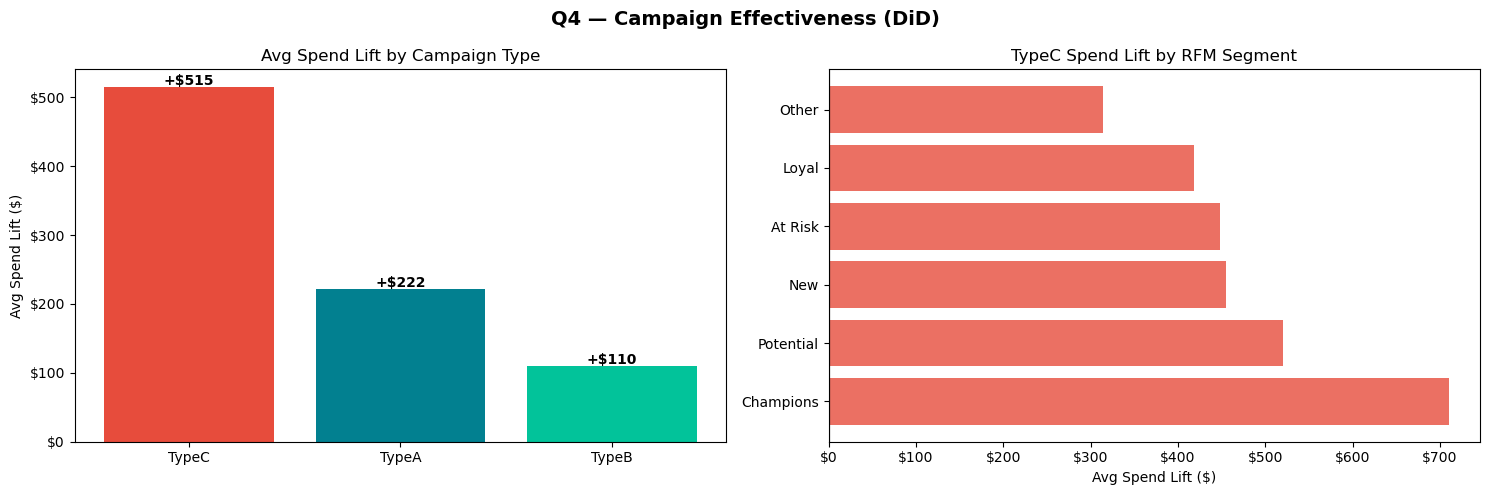

In [77]:
# Q4c — DiD lift by RFM segment (SQL joined to MongoDB RFM output)
SQL_Q4C = """
WITH events AS (
    SELECT ct.household_key, ct.campaign_id, cd.campaign_type, cd.start_day, cd.end_day
    FROM campaign_table ct
    JOIN dim_campaigns cd ON ct.campaign_id = cd.campaign_id
),
pre AS (
    SELECT e.household_key, e.campaign_id,
           COALESCE(SUM(t.sales_value), 0) AS pre_spend
    FROM events e
    JOIN fact_transactions t
      ON t.household_key = e.household_key
     AND t.day >= e.start_day - 28 AND t.day < e.start_day
    GROUP BY e.household_key, e.campaign_id
),
dur AS (
    SELECT e.household_key, e.campaign_id,
           COALESCE(SUM(t.sales_value), 0) AS dur_spend
    FROM events e
    JOIN fact_transactions t
      ON t.household_key = e.household_key
     AND t.day >= e.start_day AND t.day <= e.end_day
    GROUP BY e.household_key, e.campaign_id
)
SELECT
    e.household_key,
    e.campaign_type,
    COALESCE(p.pre_spend, 0) AS pre_spend,
    COALESCE(d.dur_spend, 0) AS dur_spend,
    COALESCE(d.dur_spend, 0) - COALESCE(p.pre_spend, 0) AS spend_lift
FROM events e
LEFT JOIN pre p ON p.household_key = e.household_key AND p.campaign_id = e.campaign_id
LEFT JOIN dur d ON d.household_key = e.household_key AND d.campaign_id = e.campaign_id
WHERE COALESCE(p.pre_spend, 0) > 0
"""

with engine.connect() as conn:
    df_did_raw = pd.read_sql(text(SQL_Q4C), conn)

# Join RFM from MongoDB
df_did_rfm = df_did_raw.merge(df_rfm, on='household_key', how='left')
df_did_rfm['rfm_segment'] = df_did_rfm['rfm_segment'].fillna('Unknown')

did_by_rfm = (
    df_did_rfm.groupby(['rfm_segment', 'campaign_type'])['spend_lift']
    .mean().round(2).reset_index()
    .rename(columns={'spend_lift': 'avg_spend_lift'})
    .sort_values(['campaign_type', 'avg_spend_lift'], ascending=[True, False])
)

print('Avg spend lift by RFM segment × campaign type:')
print(did_by_rfm.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Q4 — Campaign Effectiveness (DiD)', fontweight='bold', fontsize=14)

type_colours = {'TypeA': '#028090', 'TypeB': '#02C39A', 'TypeC': '#E74C3C'}

# Chart 1: Lift by campaign type
bars = axes[0].bar(df_did.campaign_type,
                   df_did.avg_spend_lift,
                   color=[type_colours.get(t, '#888') for t in df_did.campaign_type])
for bar, v in zip(bars, df_did.avg_spend_lift):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 3,
                 f'+${v:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Avg Spend Lift by Campaign Type')
axes[0].set_ylabel('Avg Spend Lift ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Chart 2: Lift by RFM segment for TypeC
typec = did_by_rfm[did_by_rfm.campaign_type == 'TypeC'].sort_values('avg_spend_lift', ascending=False)
if not typec.empty:
    axes[1].barh(typec.rfm_segment, typec.avg_spend_lift, color='#E74C3C', alpha=0.8)
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title('TypeC Spend Lift by RFM Segment')
    axes[1].set_xlabel('Avg Spend Lift ($)')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [78]:
# Q4d — Campaign exposure by spend quintile (selection bias check)
SQL_Q4D = """
WITH hh_spend AS (
    SELECT household_key, SUM(sales_value) AS lifetime_spend
    FROM fact_transactions
    GROUP BY household_key
),
quintiles AS (
    SELECT
        household_key,
        lifetime_spend,
        NTILE(5) OVER (ORDER BY lifetime_spend) AS spend_quintile
    FROM hh_spend
),
exposed AS (
    SELECT DISTINCT household_key FROM campaign_table
)
SELECT
    q.spend_quintile,
    COUNT(*) AS n_households,
    ROUND(MIN(q.lifetime_spend)::numeric, 0) AS min_spend,
    ROUND(MAX(q.lifetime_spend)::numeric, 0) AS max_spend,
    COUNT(e.household_key)                   AS n_exposed,
    ROUND(COUNT(e.household_key) * 100.0 /
          COUNT(*)::numeric, 1)              AS exposure_rate_pct
FROM quintiles q
LEFT JOIN exposed e USING (household_key)
GROUP BY q.spend_quintile
ORDER BY q.spend_quintile
"""

with engine.connect() as conn:
    df_bias = pd.read_sql(text(SQL_Q4D), conn)

ratio = (df_bias.exposure_rate_pct.iloc[4] / df_bias.exposure_rate_pct.iloc[0])
print(df_bias.to_string(index=False))
print(f'\nTop/bottom quintile exposure ratio: {ratio:.1f}x')

 spend_quintile  n_households  min_spend  max_spend  n_exposed  exposure_rate_pct
              1           161     646.00   2,640.00        132              82.00
              2           160   2,644.00   3,871.00        153              95.60
              3           160   3,887.00   5,532.00        158              98.80
              4           160   5,535.00   8,132.00        159              99.40
              5           160   8,216.00  27,860.00        158              98.80

Top/bottom quintile exposure ratio: 1.2x


---
## Section 6 — Q5: Trade-Down Under Price Pressure

**Business question:** As cumulative price pressure rose from 2023 to 2024, did households
shift their spend toward cheaper product tiers?

Method: Classify commodities as Budget (bottom price quartile) or Premium (top price quartile)
by average unit price. Track the Budget share of spend per household per week over time
alongside the macro PPD index. A rising Budget share concurrent with rising PPD confirms trade-down.

In [79]:
# Q5a — Classify commodities into price tiers by avg unit price
SQL_Q5A = """
WITH unit_prices AS (
    SELECT
        p.commodity,
        SUM(t.sales_value) / NULLIF(SUM(t.quantity), 0) AS avg_unit_price
    FROM fact_transactions t
    JOIN dim_products p USING (product_id)
    WHERE p.commodity IS NOT NULL
      AND p.commodity NOT ILIKE '%COUPON%'
      AND p.commodity NOT ILIKE '%MISC%'
      AND t.quantity > 0
    GROUP BY p.commodity
    HAVING SUM(t.quantity) >= 50
)
SELECT
    commodity,
    ROUND(avg_unit_price::numeric, 3) AS avg_unit_price,
    NTILE(4) OVER (ORDER BY avg_unit_price) AS price_quartile,
    CASE NTILE(4) OVER (ORDER BY avg_unit_price)
        WHEN 1 THEN 'Budget'
        WHEN 2 THEN 'Low-Mid'
        WHEN 3 THEN 'High-Mid'
        WHEN 4 THEN 'Premium'
    END AS price_tier
FROM unit_prices
ORDER BY avg_unit_price
"""

with engine.connect() as conn:
    df_tiers = pd.read_sql(text(SQL_Q5A), conn)

print(f'Commodities classified: {len(df_tiers)}')
print(df_tiers.price_tier.value_counts().to_string())

Commodities classified: 271
price_tier
Budget      68
Low-Mid     68
High-Mid    68
Premium     67


In [80]:
from sqlalchemy import text
import pandas as pd

# Q5b — Weekly budget-share trend vs PPD index
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS temp_price_tiers"))
    conn.execute(text("""
        CREATE TEMP TABLE temp_price_tiers AS
        WITH unit_prices AS (
            SELECT
                p.commodity,
                SUM(t.sales_value) / NULLIF(SUM(t.quantity), 0) AS avg_unit_price
            FROM fact_transactions t
            JOIN dim_products p USING (product_id)
            WHERE p.commodity IS NOT NULL
              AND p.commodity NOT ILIKE '%COUPON%'
              AND p.commodity NOT ILIKE '%MISC%'
              AND t.quantity > 0
            GROUP BY p.commodity
            HAVING SUM(t.quantity) >= 50
        )
        SELECT
            commodity,
            CASE NTILE(4) OVER (ORDER BY avg_unit_price)
                WHEN 1 THEN 'Budget'
                WHEN 2 THEN 'Low-Mid'
                WHEN 3 THEN 'High-Mid'
                WHEN 4 THEN 'Premium'
            END AS price_tier
        FROM unit_prices
    """))

    SQL_Q5B = """
    SELECT
        ec.week_num,
        ec.year,
        MIN(ec.calendar_date) AS week_start_date,
        ROUND(AVG(m.ppd_index)::numeric, 4) AS ppd_index,
        ROUND(
            SUM(CASE WHEN pt.price_tier = 'Budget' THEN t.sales_value ELSE 0 END)
            * 100.0 / NULLIF(SUM(t.sales_value), 0)::numeric,
            2
        ) AS budget_share_pct,
        ROUND(
            SUM(CASE WHEN pt.price_tier = 'Premium' THEN t.sales_value ELSE 0 END)
            * 100.0 / NULLIF(SUM(t.sales_value), 0)::numeric,
            2
        ) AS premium_share_pct
    FROM fact_transactions t
    JOIN dim_products p USING (product_id)
    JOIN temp_price_tiers pt ON pt.commodity = p.commodity
    JOIN ext_calendar ec ON ec.day_int = t.day
    JOIN ext_macro_weekly m ON m.week_num = ec.week_num
    WHERE NOT ec.is_rampup
      AND NOT ec.is_truncation
    GROUP BY ec.week_num, ec.year
    ORDER BY ec.week_num
    """

    df_trade = pd.read_sql(text(SQL_Q5B), conn)

corr = df_trade["ppd_index"].corr(df_trade["budget_share_pct"])
print(f"PPD ↔ Budget share correlation : {corr:+.3f}")
print(f"Budget share range: {df_trade['budget_share_pct'].min():.1f}% - {df_trade['budget_share_pct'].max():.1f}%")
print(f"Premium share range: {df_trade['premium_share_pct'].min():.1f}% - {df_trade['premium_share_pct'].max():.1f}%")
print(f"PPD range: {df_trade['ppd_index'].min():.2f} - {df_trade['ppd_index'].max():.2f}")

PPD ↔ Budget share correlation : +0.036
Budget share range: 27.9% - 36.6%
Premium share range: 17.8% - 23.2%
PPD range: 1.40 - 5.50


Budget share by PPD bucket × demographic group:
   ppd_bucket c3_group  n_households  budget_share_pct  premium_share_pct
High PPD (4+)     High            27             27.53              22.49
High PPD (4+)      Low           212             32.29              20.35
High PPD (4+)      Mid           562             30.89              19.71
Low PPD (< 2)     High            26             26.42              24.77
Low PPD (< 2)      Low           203             30.30              20.42
Low PPD (< 2)      Mid           546             30.36              20.33
Mid PPD (2-4)     High            27             27.36              23.53
Mid PPD (2-4)      Low           211             31.80              21.00
Mid PPD (2-4)      Mid           560             31.74              19.48


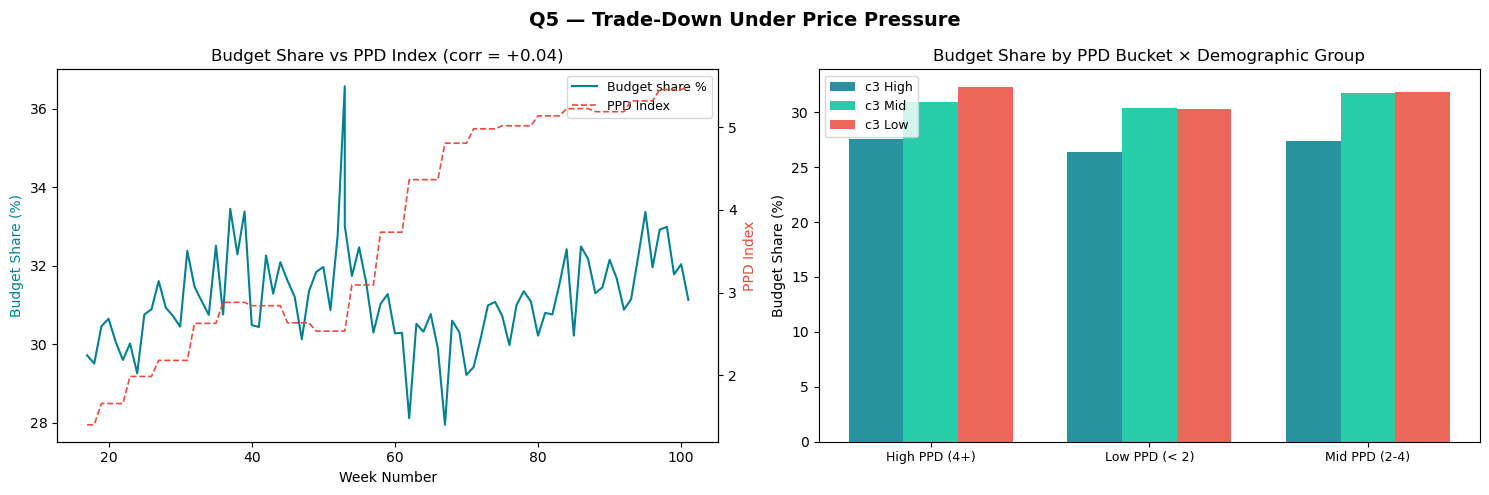

In [81]:
# Q5c — Trade-down by demographic group (classification_3: High/Mid/Low)
SQL_Q5C = """
WITH hh_demo AS (
    SELECT
        d.household_key,
        CASE
            WHEN d.classification_3 IN ('Level10','Level11','Level12') THEN 'High'
            WHEN d.classification_3 IN ('Level1','Level2','Level3')    THEN 'Low'
            ELSE 'Mid'
        END AS c3_group
    FROM dim_demographics d
    WHERE d.classification_3 IS NOT NULL
),
macro AS (
    SELECT
        ec.week_num,
        m.ppd_index,
        CASE WHEN m.ppd_index < 2 THEN 'Low PPD (< 2)'
             WHEN m.ppd_index < 4 THEN 'Mid PPD (2-4)'
             ELSE                      'High PPD (4+)'
        END AS ppd_bucket
    FROM ext_macro_weekly m
    JOIN ext_calendar ec ON ec.week_num = m.week_num
    WHERE ec.is_rampup = FALSE AND ec.is_truncation = FALSE
    GROUP BY ec.week_num, m.ppd_index
)
SELECT
    ma.ppd_bucket,
    hd.c3_group,
    COUNT(DISTINCT t.household_key)    AS n_households,
    ROUND(
        SUM(CASE WHEN pt.price_tier = 'Budget' THEN t.sales_value ELSE 0 END)
        * 100.0 / NULLIF(SUM(t.sales_value), 0)::numeric
    , 2) AS budget_share_pct,
    ROUND(
        SUM(CASE WHEN pt.price_tier = 'Premium' THEN t.sales_value ELSE 0 END)
        * 100.0 / NULLIF(SUM(t.sales_value), 0)::numeric
    , 2) AS premium_share_pct
FROM fact_transactions t
JOIN dim_products p USING (product_id)
JOIN temp_price_tiers pt ON pt.commodity = p.commodity
JOIN ext_calendar ec ON ec.day_int = t.day
JOIN macro ma ON ma.week_num = ec.week_num
JOIN hh_demo hd ON hd.household_key = t.household_key
WHERE ec.is_rampup = FALSE AND ec.is_truncation = FALSE
GROUP BY ma.ppd_bucket, hd.c3_group
ORDER BY ma.ppd_bucket, hd.c3_group
"""

with engine.connect() as conn:
    df_demo_trade = pd.read_sql(text(SQL_Q5C), conn)

print('Budget share by PPD bucket × demographic group:')
print(df_demo_trade.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Q5 — Trade-Down Under Price Pressure', fontweight='bold', fontsize=14)

# Chart 1: Budget share over time vs PPD
ax1 = axes[0]
ax1b = ax1.twinx()
ax1.plot(df_trade.week_num, df_trade.budget_share_pct,
         color='#028090', linewidth=1.5, label='Budget share %')
ax1b.plot(df_trade.week_num, df_trade.ppd_index,
          color='#E74C3C', linewidth=1.2, linestyle='--', label='PPD Index')
ax1.set_xlabel('Week Number')
ax1.set_ylabel('Budget Share (%)', color='#028090')
ax1b.set_ylabel('PPD Index', color='#E74C3C')
ax1.set_title(f'Budget Share vs PPD Index (corr = {corr:+.2f})')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

# Chart 2: Budget share by demographic group × PPD bucket
pivot = df_demo_trade.pivot(index='ppd_bucket', columns='c3_group', values='budget_share_pct')
x = np.arange(len(pivot))
width = 0.25
group_colours = {'High': '#028090', 'Mid': '#02C39A', 'Low': '#E74C3C'}
for i, grp in enumerate(['High', 'Mid', 'Low']):
    if grp in pivot.columns:
        axes[1].bar(x + i*width, pivot[grp], width,
                    label=f'c3 {grp}', color=group_colours[grp], alpha=0.85)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(pivot.index, fontsize=9)
axes[1].set_ylabel('Budget Share (%)')
axes[1].set_title('Budget Share by PPD Bucket × Demographic Group')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 7 — Customer Segmentation & At-Risk Identification

SQL-based customer tiering using spend quintiles (CLV proxy) and recency thresholds
(churn proxy). No machine learning — all computed directly from the star schema.

In [82]:
# S7a — Spend-tier segmentation using NTILE (CLV proxy)
SQL_S7A = """
WITH hh_metrics AS (
    SELECT
        t.household_key,
        ROUND(SUM(t.sales_value)::numeric, 2)         AS lifetime_spend,
        COUNT(DISTINCT t.basket_id)                   AS total_trips,
        ROUND(SUM(t.sales_value) /
              NULLIF(COUNT(DISTINCT t.basket_id),0)::numeric, 2) AS avg_basket,
        MAX(t.day)                                    AS last_day,
        (SELECT MAX(day) FROM fact_transactions) - MAX(t.day) AS days_since_last
    FROM fact_transactions t
    GROUP BY t.household_key
),
tiers AS (
    SELECT *,
        CASE NTILE(3) OVER (ORDER BY lifetime_spend DESC)
            WHEN 1 THEN 'High Value'
            WHEN 2 THEN 'Mid Value'
            WHEN 3 THEN 'Low Value'
        END AS clv_tier,
        CASE WHEN days_since_last >= 30 THEN 'At Risk' ELSE 'Active' END AS risk_status
    FROM hh_metrics
)
SELECT
    clv_tier,
    risk_status,
    COUNT(*)                                          AS n_households,
    ROUND(AVG(lifetime_spend)::numeric, 0)            AS avg_lifetime_spend,
    ROUND(AVG(total_trips)::numeric, 1)               AS avg_trips,
    ROUND(AVG(avg_basket)::numeric, 2)                AS avg_basket,
    ROUND(AVG(days_since_last)::numeric, 1)           AS avg_days_absent
FROM tiers
GROUP BY clv_tier, risk_status
ORDER BY clv_tier, risk_status
"""

with engine.connect() as conn:
    df_tiers_summary = pd.read_sql(text(SQL_S7A), conn)

print('Customer tier × risk status summary:')
print(df_tiers_summary.to_string(index=False))

Customer tier × risk status summary:
  clv_tier risk_status  n_households  avg_lifetime_spend  avg_trips  avg_basket  avg_days_absent
High Value      Active           259            9,813.00     259.00       47.82             2.70
High Value     At Risk             8            9,013.00     274.60       44.55            61.50
 Low Value      Active           252            2,390.00     118.20       25.53             5.70
 Low Value     At Risk            15            1,944.00      83.30       29.58            74.20
 Mid Value      Active           253            4,722.00     152.30       36.75             4.70
 Mid Value     At Risk            14            4,142.00     107.50       46.38            73.40


In [83]:
# S7b — Priority retention list: High/Mid Value + At Risk (days_since_last >= 30)
SQL_S7B = """
WITH hh_metrics AS (
    SELECT
        t.household_key,
        ROUND(SUM(t.sales_value)::numeric, 2)        AS lifetime_spend,
        COUNT(DISTINCT t.basket_id)                  AS total_trips,
        (SELECT MAX(day) FROM fact_transactions) - MAX(t.day) AS days_since_last
    FROM fact_transactions t
    GROUP BY t.household_key
),
tiers AS (
    SELECT *,
        CASE NTILE(3) OVER (ORDER BY lifetime_spend DESC)
            WHEN 1 THEN 'High Value'
            WHEN 2 THEN 'Mid Value'
            WHEN 3 THEN 'Low Value'
        END AS clv_tier
    FROM hh_metrics
)
SELECT
    household_key,
    clv_tier,
    lifetime_spend,
    total_trips,
    days_since_last
FROM tiers
WHERE days_since_last >= 30
  AND clv_tier IN ('High Value','Mid Value')
ORDER BY clv_tier, lifetime_spend DESC
"""

with engine.connect() as conn:
    df_priority = pd.read_sql(text(SQL_S7B), conn)

print(f'Priority retention audience: {len(df_priority)} households')
print(df_priority.groupby('clv_tier').size().to_string())
print()
print('Top 10 by lifetime spend:')
print(df_priority.head(10).to_string(index=False))

Priority retention audience: 22 households
clv_tier
High Value     8
Mid Value     14

Top 10 by lifetime spend:
 household_key   clv_tier  lifetime_spend  total_trips  days_since_last
           232 High Value       12,695.57          631               39
           149 High Value       11,920.93          215               60
          2318 High Value       10,685.72          366               89
          2097 High Value        8,823.83          202               66
          1305 High Value        7,552.93          373               30
          1396 High Value        7,177.06          229               91
           492 High Value        7,148.28          117               78
          1060 High Value        6,096.93           64               39
          1091  Mid Value        5,617.40          116               45
          2420  Mid Value        4,583.46          102               45


---
## Section 8 — MongoDB Customer 360 Queries

Direct aggregation queries against the Customer 360 document store.
Answers include RFM segment distribution, high-value at-risk households,
and the under-targeted 'Other' segment finding.

In [84]:
# M1 — RFM segment distribution
pipeline_rfm = [
    {'$group': {
        '_id': '$rfm_segment',
        'n_households': {'$sum': 1},
        'avg_lifetime_spend': {'$avg': '$financial_metrics.lifetime_spend'},
        'avg_trips': {'$avg': '$financial_metrics.total_trips'},
        'avg_days_absent': {'$avg': '$financial_metrics.days_since_last_purchase'}
    }},
    {'$sort': {'n_households': -1}}
]

df_rfm_dist = pd.DataFrame(coll.aggregate(pipeline_rfm))
df_rfm_dist = df_rfm_dist.rename(columns={'_id': 'rfm_segment'})
df_rfm_dist[['avg_lifetime_spend','avg_trips','avg_days_absent']] = \
    df_rfm_dist[['avg_lifetime_spend','avg_trips','avg_days_absent']].round(1)

total = df_rfm_dist.n_households.sum()
df_rfm_dist['pct'] = (df_rfm_dist.n_households / total * 100).round(1)

print('RFM segment distribution (MongoDB Customer 360):')
print(df_rfm_dist.to_string(index=False))

RFM segment distribution (MongoDB Customer 360):
rfm_segment  n_households  avg_lifetime_spend  avg_trips  avg_days_absent   pct
      Other           262            3,349.60      91.60            12.90 28.40
    At Risk           139            6,104.80     188.40            15.80 15.00
  Champions           130           10,407.50     325.60             0.40 14.10
       None           123                0.00       0.00             0.00 13.30
      Loyal           122            5,807.20     258.20             1.60 13.20
  Potential            83            6,123.30     127.20             1.20  9.00
        New            65            3,105.60      88.40             0.60  7.00


In [85]:
# M2 — High-value at-risk households: days absent >= 30, lifetime spend >= $3,000
pipeline_atrisk = [
    {'$match': {
        'financial_metrics.days_since_last_purchase': {'$gte': 30},
        'financial_metrics.lifetime_spend': {'$gte': 3000}
    }},
    {'$project': {
        '_id': 1,
        'rfm_segment': 1,
        'lifetime_spend': '$financial_metrics.lifetime_spend',
        'days_absent': '$financial_metrics.days_since_last_purchase',
        'avg_basket': '$financial_metrics.avg_basket_value',
        'n_campaigns': {'$size': {'$ifNull': ['$active_campaigns', []]}}
    }},
    {'$sort': {'lifetime_spend': -1}},
    {'$limit': 20}
]

df_atrisk = pd.DataFrame(coll.aggregate(pipeline_atrisk))
print(f'High-value at-risk households (spend >= $3K, absent >= 30d): {len(df_atrisk)}')
print(df_atrisk.to_string(index=False))

High-value at-risk households (spend >= $3K, absent >= 30d): 20
    _id rfm_segment  lifetime_spend  days_absent  avg_basket  n_campaigns
 HH_232     At Risk       12,695.57           39       20.12            7
 HH_149     At Risk       11,920.93           60       55.45            8
HH_2318     At Risk       10,685.72           89       29.20           13
HH_2097     At Risk        8,823.83           66       43.68            6
HH_1305     At Risk        7,552.93           30       20.25            7
HH_1396     At Risk        7,177.06           91       31.34            5
 HH_492       Other        7,148.28           78       61.10            8
HH_1060       Other        6,096.93           39       95.26            9
HH_1091       Other        5,617.40           45       48.43            5
HH_2420       Other        4,583.46           45       44.94            5
HH_1980       Other        4,443.15           49       82.28            1
 HH_682     At Risk        4,438.29          142

Avg campaign exposure by RFM segment:
rfm_segment  avg_campaigns  avg_spend   n
  Champions           7.60  10,407.52 130
    At Risk           6.27   6,104.82 139
  Potential           6.24   6,123.33  83
      Loyal           6.04   5,807.22 122
No activity           5.45       0.00 123
      Other           3.46   3,349.57 262
        New           2.94   3,105.60  65


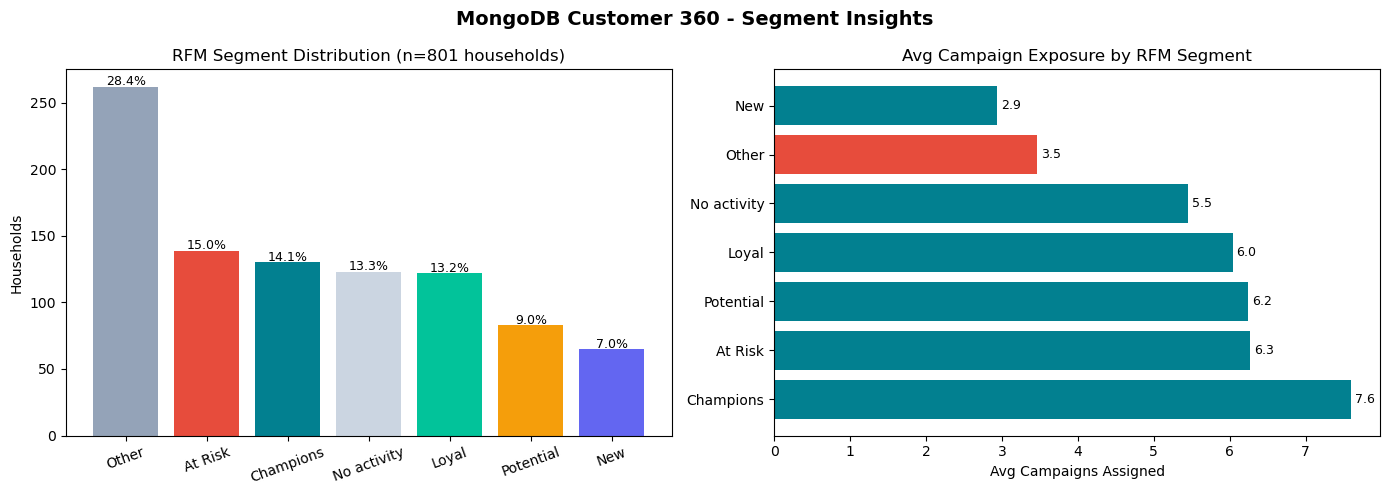

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# M3 - Under-targeted 'Other' segment: avg campaigns vs rest
pipeline_under = [
    {'$project': {
        'rfm_segment': {'$ifNull': ['$rfm_segment', 'No activity']},
        'n_campaigns': {'$size': {'$ifNull': ['$active_campaigns', []]}},
        'lifetime_spend': {'$ifNull': ['$financial_metrics.lifetime_spend', 0]}
    }},
    {'$group': {
        '_id': '$rfm_segment',
        'avg_campaigns': {'$avg': '$n_campaigns'},
        'avg_spend': {'$avg': '$lifetime_spend'},
        'n': {'$sum': 1}
    }},
    {'$sort': {'avg_campaigns': -1}}
]

df_targeting = pd.DataFrame(list(coll.aggregate(pipeline_under)))
df_targeting = df_targeting.rename(columns={'_id': 'rfm_segment'})

df_targeting['rfm_segment'] = df_targeting['rfm_segment'].astype(str)
df_targeting['avg_campaigns'] = pd.to_numeric(df_targeting['avg_campaigns'], errors='coerce')
df_targeting['avg_spend'] = pd.to_numeric(df_targeting['avg_spend'], errors='coerce')
df_targeting['n'] = pd.to_numeric(df_targeting['n'], errors='coerce')
df_targeting[['avg_campaigns', 'avg_spend']] = df_targeting[['avg_campaigns', 'avg_spend']].round(2)

print('Avg campaign exposure by RFM segment:')
print(df_targeting.to_string(index=False))

# Clean plotting copy of df_rfm_dist
plot_rfm = df_rfm_dist.copy()
plot_rfm['rfm_segment'] = plot_rfm['rfm_segment'].fillna('No activity').replace({None: 'No activity'}).astype(str)
plot_rfm['n_households'] = pd.to_numeric(plot_rfm['n_households'], errors='coerce')
plot_rfm['pct'] = pd.to_numeric(plot_rfm['pct'], errors='coerce')

# Plot
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MongoDB Customer 360 - Segment Insights', fontweight='bold', fontsize=14)

# RFM distribution
seg_colours = {
    'Champions': '#028090',
    'Loyal': '#02C39A',
    'Potential': '#F59E0B',
    'At Risk': '#E74C3C',
    'New': '#6366F1',
    'Other': '#94A3B8',
    'No activity': '#CBD5E1'
}

x_labels = plot_rfm['rfm_segment'].tolist()
x_vals = plot_rfm['n_households'].tolist()
x_pct = plot_rfm['pct'].tolist()
x_colours = [seg_colours.get(s, '#888888') for s in x_labels]

x = range(len(x_labels))
axes[0].bar(x, x_vals, color=x_colours)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(x_labels, rotation=20)
axes[0].set_title('RFM Segment Distribution (n=801 households)')
axes[0].set_ylabel('Households')

for i, (n, p) in enumerate(zip(x_vals, x_pct)):
    axes[0].text(i, n + 1, f'{p:.1f}%', ha='center', fontsize=9)

# Campaign exposure
y_labels = df_targeting['rfm_segment'].tolist()
y_vals = df_targeting['avg_campaigns'].tolist()
y_colours = ['#E74C3C' if s == 'Other' else '#028090' for s in y_labels]

y = range(len(y_labels))
axes[1].barh(y, y_vals, color=y_colours)
axes[1].set_yticks(list(y))
axes[1].set_yticklabels(y_labels)
axes[1].set_title('Avg Campaign Exposure by RFM Segment')
axes[1].set_xlabel('Avg Campaigns Assigned')

for i, v in enumerate(y_vals):
    axes[1].text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [87]:
# M4 — GeoRFM: nearest store distribution + spend by store
pipeline_store = [
    {'$match': {'nearest_store.store_id': {'$exists': True}}},
    {'$group': {
        '_id': '$nearest_store.store_id',
        'n_households': {'$sum': 1},
        'avg_lifetime_spend': {'$avg': '$financial_metrics.lifetime_spend'},
        'champions': {'$sum': {'$cond': [{'$eq': ['$rfm_segment','Champions']}, 1, 0]}}
    }},
    {'$sort': {'n_households': -1}},
    {'$limit': 10}
]

df_stores = pd.DataFrame(coll.aggregate(pipeline_store))
if not df_stores.empty:
    df_stores = df_stores.rename(columns={'_id': 'store_id'})
    df_stores[['avg_lifetime_spend']] = df_stores[['avg_lifetime_spend']].round(0)
    print('Top stores by household catchment:')
    print(df_stores.to_string(index=False))
else:
    print('No store geo data available in current documents.')

Top stores by household catchment:
 store_id  n_households  avg_lifetime_spend  champions
      367           893            4,813.00        123
      369            11            7,701.00          3
      368            11            6,818.00          3
      370             9            4,445.00          1


In [88]:
# Final summary print
print('=' * 65)
print('PHASE 2 DATABASE ANALYSIS — KEY FINDINGS SUMMARY')
print('=' * 65)

ss = df_ss.iloc[0]
print(f'\nQ1 — Spending Trends')
print(f'  Avg weekly spend (steady-state) : ${ss.avg_weekly_spend:,.0f}')
print(f'  YoY growth (2023→2024)          : +{merged.yoy_pct.mean():.1f}%')
print(f'  Artefact weeks excluded         : 16 ramp-up + 1 truncation')

top_c = df_signal.iloc[0]
print(f'\nQ2 — Demographic Influences')
print(f'  Strongest signal : {top_c.classification} (${top_c.spend_spread:,.0f} spend spread)')
print(f'  classification_2 Group X premium : ${premium:,.0f} over Group Y')

top_d = df_dept.iloc[0]
print(f'\nQ3 — Category Growth')
print(f'  GROCERY revenue share : {top_d.revenue_share_pct:.1f}%')
print(f'  Top 5 departments     : {top5_cum:.1f}% of all revenue')

tc_row = df_did[df_did.campaign_type=='TypeC']
if not tc_row.empty:
    print(f'\nQ4 — Campaign Effectiveness (DiD)')
    print(f'  TypeC lift : +${tc_row.avg_spend_lift.iloc[0]:,.0f}  ({tc_row.avg_pct_lift.iloc[0]:+.1f}%)')
    print(f'  TypeA lift : +${df_did[df_did.campaign_type=="TypeA"].avg_spend_lift.iloc[0]:,.0f}')
    print(f'  TypeB lift : +${df_did[df_did.campaign_type=="TypeB"].avg_spend_lift.iloc[0]:,.0f}')

print(f'\nQ5 — Trade-Down')
print(f'  PPD ↔ Budget share correlation : {corr:+.3f}')

print(f'\nSegmentation (SQL tiers)')
hv_ar = df_tiers_summary[(df_tiers_summary.clv_tier=='High Value') &
                          (df_tiers_summary.risk_status=='At Risk')]
mv_ar = df_tiers_summary[(df_tiers_summary.clv_tier=='Mid Value') &
                          (df_tiers_summary.risk_status=='At Risk')]
if not hv_ar.empty:
    print(f'  High Value + At Risk : {hv_ar.n_households.iloc[0]} households')
if not mv_ar.empty:
    print(f'  Mid Value  + At Risk : {mv_ar.n_households.iloc[0]} households')

print('=' * 65)

PHASE 2 DATABASE ANALYSIS — KEY FINDINGS SUMMARY

Q1 — Spending Trends
  Avg weekly spend (steady-state) : $49,050
  YoY growth (2023→2024)          : +33.5%
  Artefact weeks excluded         : 16 ramp-up + 1 truncation

Q2 — Demographic Influences
  Strongest signal : classification_3 ($6,693 spend spread)
  classification_2 Group X premium : $868 over Group Y

Q3 — Category Growth
  GROCERY revenue share : 50.2%
  Top 5 departments     : 84.7% of all revenue

Q4 — Campaign Effectiveness (DiD)
  TypeC lift : +$515  (+287.8%)
  TypeA lift : +$222
  TypeB lift : +$110

Q5 — Trade-Down
  PPD ↔ Budget share correlation : +0.036

Segmentation (SQL tiers)
  High Value + At Risk : 8 households
  Mid Value  + At Risk : 14 households


In [89]:
benchmarks = []

result, df_ss = benchmark_sql("Q1b: Steady-state summary", SQL_Q1B, engine, repeats=5)
benchmarks.append(result)

result, df_dept = benchmark_sql("Q3a: Department revenue share", SQL_Q3A, engine, repeats=5)
benchmarks.append(result)

result, df_yoy_dept = benchmark_sql("Q3b: YoY revenue growth by department", SQL_Q3B, engine, repeats=5)
benchmarks.append(result)

result, df_targeting = benchmark_mongo("M3: Avg campaign exposure by RFM segment", coll, pipeline_under, repeats=5)
benchmarks.append(result)

df_benchmarks = pd.DataFrame(benchmarks)
print(df_benchmarks.sort_values("avg_ms", ascending=False).to_string(index=False))

                            metric_label source  avg_ms  median_ms  p95_ms  min_ms  max_ms  runs  rows                      recorded_at
   Q3b: YoY revenue growth by department    sql  398.91     399.08  399.92  397.37  400.03     5    15 2026-03-11 16:48:38.707837+00:00
           Q3a: Department revenue share    sql  306.46     300.52  340.32  282.25  348.16     5    41 2026-03-11 16:48:36.712288+00:00
               Q1b: Steady-state summary    sql  211.31     205.68  229.03  203.52  234.06     5     1 2026-03-11 16:48:35.179061+00:00
M3: Avg campaign exposure by RFM segment  mongo    4.87       4.82    5.08    4.76    5.13     5     7 2026-03-11 16:48:38.733175+00:00
